# Per-Visit LOWESS Exploration of Fetal Weight Trajectories

Notation: $i$ = subject, $j = 1,2,3,4$ = measurement occasion.

**Tasks**
1. $Y_{ij}(t_{ij})$ vs $t_{ij}$ with LOWESS, one figure per $j$.
2. $Y_{ij}(t_{ij}) - \bar{y}_j$ vs $t_{ij}$ with LOWESS, one figure per $j$.
3. Both, restricted to subjects in the top 15th percentile of birthweight.

**Provenance note.** The outputs embedded below were produced by executing this
code against `longitudinal_data_processed.csv`. `statsmodels` was unavailable in
the environment where they were generated, so the LOWESS came from the bundled
reference implementation in the next cell. In Colab `statsmodels` will be
present and will be used automatically. The final cell diffs the two so you can
confirm they agree before using any figure in the paper.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "data/longitudinal_data_processed.csv"
FRAC = 0.5    # LOWESS bandwidth
NIT  = 3      # robustness iterations
TRIM = 1.0    # drop t outside [TRIM, 100-TRIM] pctile within visit; 0 disables


def _lowess_ref(x, y, frac=FRAC, it=NIT):
    """Cleveland (1979) local linear regression, tricube weights, bisquare
    robustness iterations. Reference fallback when statsmodels is absent."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    o = np.argsort(x); x, y = x[o], y[o]
    n = len(x); r = max(int(np.ceil(frac * n)), 2)

    h = np.array([np.sort(np.abs(x - x[i]))[r - 1] for i in range(n)])
    h[h == 0] = np.finfo(float).eps
    w = np.clip(np.abs((x[:, None] - x[None, :]) / h[:, None]), 0.0, 1.0)
    w = (1 - w ** 3) ** 3

    yfit = np.zeros(n); delta = np.ones(n)
    for _ in range(it + 1):
        for i in range(n):
            wi = delta * w[i]; sw = wi.sum()
            if sw <= 0:
                yfit[i] = y[i]; continue
            mx = (wi * x).sum() / sw; my = (wi * y).sum() / sw
            sxx = (wi * (x - mx) ** 2).sum()
            sxy = (wi * (x - mx) * (y - my)).sum()
            b = sxy / sxx if sxx > np.finfo(float).eps else 0.0
            yfit[i] = my + b * (x[i] - mx)
        res = y - yfit; s = np.median(np.abs(res))
        if s <= np.finfo(float).eps:
            break
        delta = np.clip(res / (6.0 * s), -1, 1)
        delta = (1 - delta ** 2) ** 2
    return np.column_stack([x, yfit])


try:
    from statsmodels.nonparametric.smoothers_lowess import lowess as _sm_lowess
    HAVE_SM = True
    def smooth(x, y):
        return _sm_lowess(y, x, frac=FRAC, it=NIT, return_sorted=True)
except ImportError:
    HAVE_SM = False
    def smooth(x, y):
        return _lowess_ref(x, y)

print("LOWESS backend:", "statsmodels" if HAVE_SM else "bundled reference")


def _selftest():
    rng = np.random.default_rng(0)
    x = rng.uniform(0, 10, 200)
    s = _lowess_ref(x, 3.0 * x - 7.0)
    assert np.max(np.abs(s[:, 1] - (3 * s[:, 0] - 7))) < 1e-8
    s2 = _lowess_ref(x, np.sin(x) + rng.normal(0, .05, 200), frac=.3)
    assert np.corrcoef(s2[:, 1], np.sin(s2[:, 0]))[0, 1] > .99
    print("reference lowess self-test passed")

_selftest()

## Load and index visits

Every subject has exactly 4 EFW records, so $j$ is the within-subject rank of `time`.
Note `bw` is stored per-row, repeated across a subject's four rows, so any
subject-level quantity must be collapsed first or birthweight gets weighted 4x.

In [2]:
df = pd.read_csv(DATA).sort_values(["id", "time"]).reset_index(drop=True)
df["j"] = df.groupby("id").cumcount() + 1

sizes = df.groupby("id").size().unique()
assert set(sizes) == {4}, f"ragged visit counts: {sizes}"
print(f"{df.id.nunique()} subjects, {len(df)} records, visits per subject: {sizes}")
print("nulls in modelled columns:",
      df[["id", "time", "efw", "bw"]].isna().sum().sum())

summ = (df.groupby("j")
          .agg(n=("efw", "size"), t_min=("time", "min"), t_max=("time", "max"),
               t_sd=("time", "std"), ybar=("efw", "mean"), y_sd=("efw", "std"))
          .round(1))
summ["ols_slope"] = [round(float(np.polyfit(g.time, g.efw, 1)[0]), 2)
                     for _, g in df.groupby("j")]
summ["cv"] = (summ.y_sd / summ.ybar).round(3)
print()
print(summ.to_string())

1120 subjects, 4480 records, visits per subject: [4]
nulls in modelled columns: 0

      n  t_min  t_max  t_sd    ybar   y_sd  ols_slope     cv
j                                                           
1  1120     84    151   8.2   215.1   48.9       5.41  0.227
2  1120    158    228   5.6   804.3  114.0      14.09  0.142
3  1120    202    246   5.0  2209.6  258.3      25.47  0.117
4  1120    232    276   5.4  3132.8  357.2      27.12  0.114


## Plotting helpers

`TRIM` matters. At the extremes of $t$ within a visit there are one or two
isolated observations and the local fit degenerates \u2014 untrimmed, the visit-2
curve swings several hundred grams off a single record at $t=228$. Excluded
points are still drawn as grey crosses. Set `TRIM = 0` to reproduce raw behaviour.

In [3]:
PHASE = {1: "~17 wk", 2: "~25 wk", 3: "~33 wk", 4: "~37 wk"}


def panel(ax, t, y, j, centered):
    ax.scatter(t, y, s=9, alpha=.30, color="#4878A8", edgecolors="none",
               label=f"observed (n={len(t)})")

    if TRIM > 0:
        lo, hi = np.percentile(t, [TRIM, 100 - TRIM])
        m = (t >= lo) & (t <= hi)
        lab = f"LOWESS (frac={FRAC}, {TRIM}-{100-TRIM} pctile of t)"
    else:
        m = np.ones(len(t), bool)
        lab = f"LOWESS (frac={FRAC}, untrimmed)"

    s = smooth(t[m], y[m])
    ax.plot(s[:, 0], s[:, 1], color="#C44E52", lw=2.2, label=lab)

    if (~m).sum():
        ax.scatter(t[~m], y[~m], s=18, color="#999", marker="x", lw=.9,
                   label=f"excluded from fit ({(~m).sum()})")

    if centered:
        ax.axhline(0, color="#555", lw=.8, ls="--", zorder=0)
        ax.set_ylabel(r"$Y_{ij}(t_{ij}) - \bar{y}_j$  (g)")
    else:
        ax.set_ylabel(r"$Y_{ij}(t_{ij})$  (g)")

    ax.set_xlabel(r"$t_{ij}$  (gestational days)")
    ax.set_title(f"Visit j = {j}  ({PHASE[j]})", fontsize=11)
    ax.legend(fontsize=8, framealpha=.9)
    ax.grid(alpha=.25, lw=.5)


def make_set(data, centered, suptitle, prefix):
    """Saves the four standalone figures Sinha asked for, displays the composite."""
    for j in range(1, 5):
        d = data[data.j == j]
        y = d.efw.values - (d.efw.values.mean() if centered else 0)
        fig, ax = plt.subplots(figsize=(7, 5))
        panel(ax, d.time.values, y, j, centered)
        fig.tight_layout()
        fig.savefig(f"{prefix}_visit{j}.png", dpi=160)
        plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
    for j in range(1, 5):
        d = data[data.j == j]
        y = d.efw.values - (d.efw.values.mean() if centered else 0)
        panel(axes.flat[j - 1], d.time.values, y, j, centered)
    fig.suptitle(suptitle, fontsize=13, y=.995)
    fig.tight_layout()
    fig.savefig(f"{prefix}_composite.png", dpi=150)
    print(f"saved {prefix}_visit1..4.png and {prefix}_composite.png")

## Task 1 — $Y_{ij}(t_{ij})$ vs $t_{ij}$, all subjects

saved task1_raw_visit1..4.png and task1_raw_composite.png


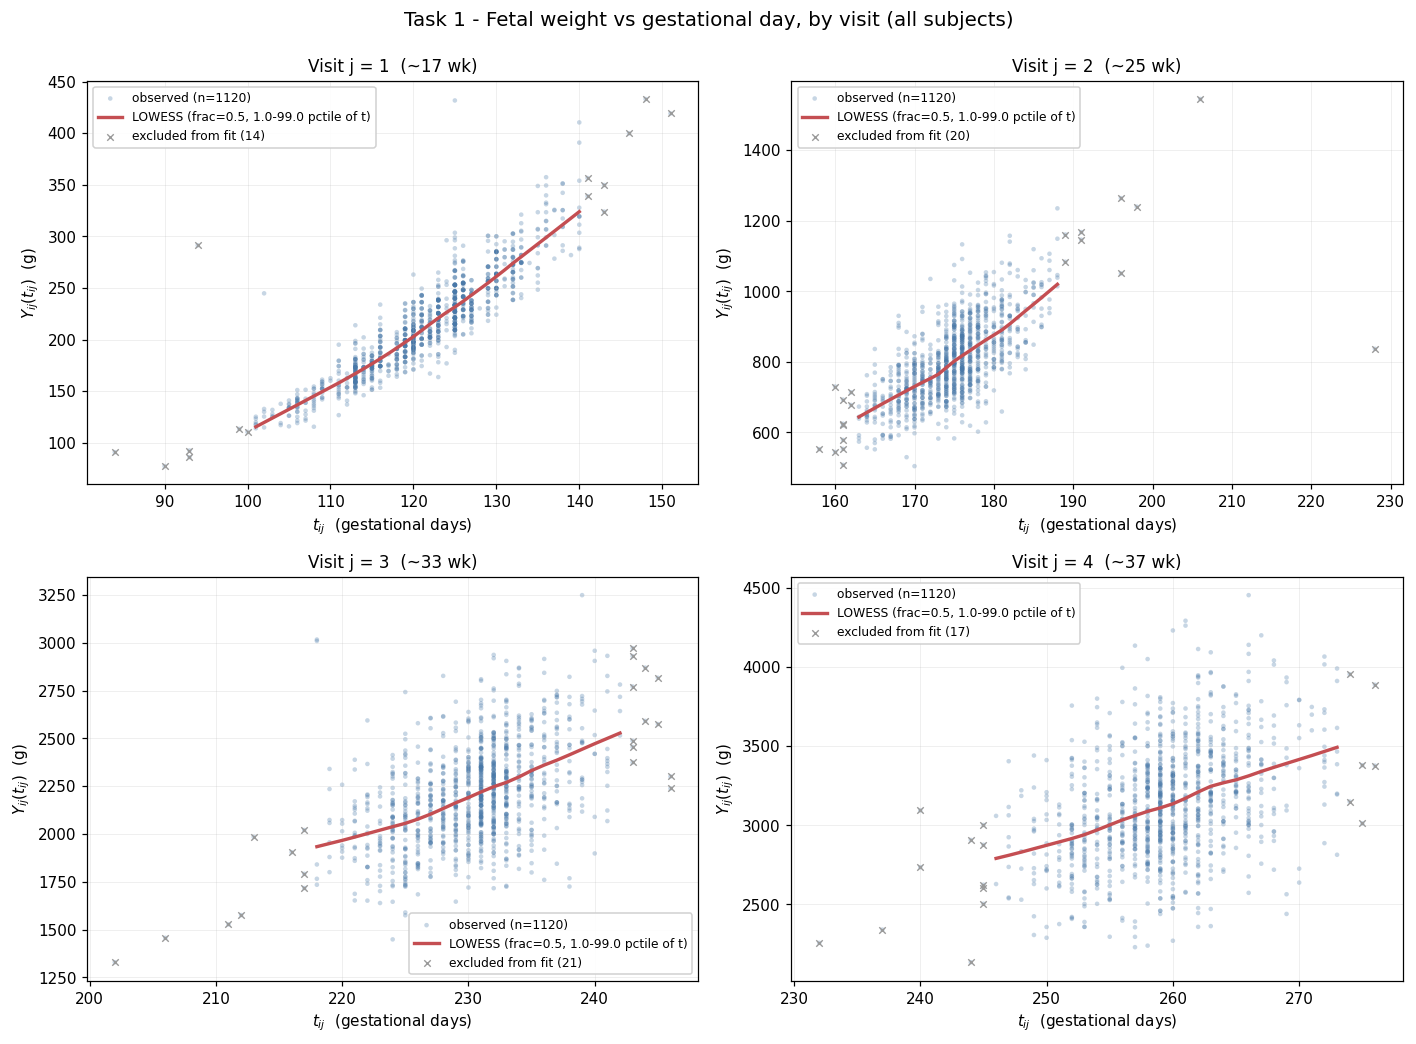

In [4]:
make_set(df, False,
         "Task 1 - Fetal weight vs gestational day, by visit (all subjects)",
         "task1_raw")

## Task 2 \u2014 $Y_{ij}(t_{ij}) - \bar{y}_j$ vs $t_{ij}$, all subjects

Subtracting $\bar{y}_j$ is a pure vertical translation within each panel, so the
LOWESS shape and slope are identical to Task 1 \u2014 only the $y$-axis origin moves.
The gain is a common gram scale across the four panels.

saved task2_centered_visit1..4.png and task2_centered_composite.png


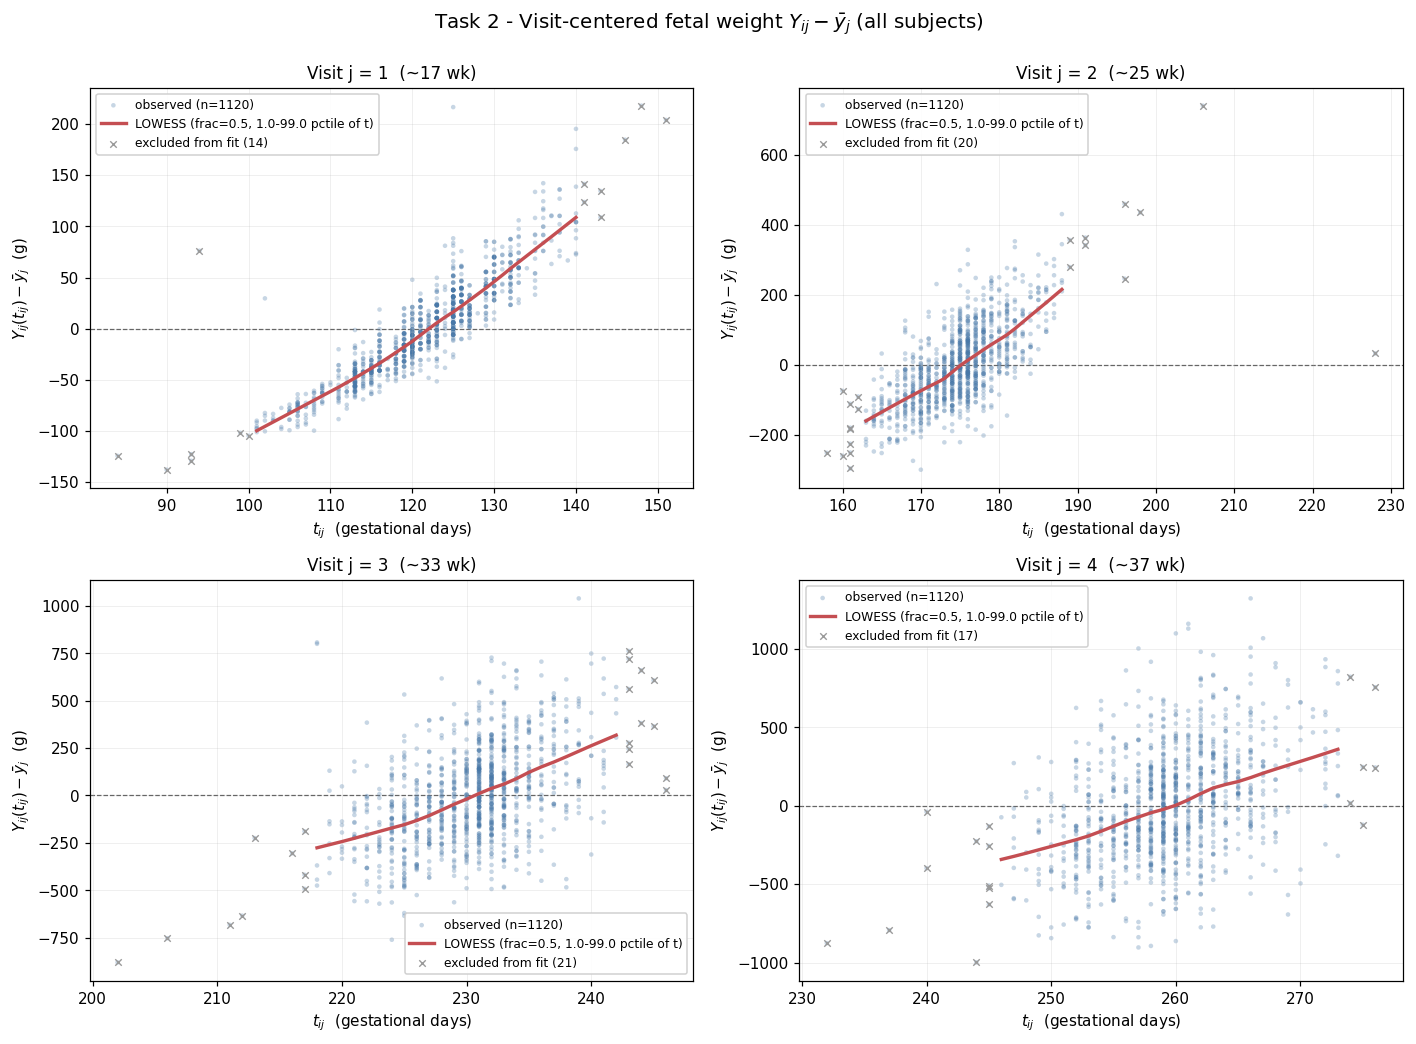

In [5]:
make_set(df, True,
         r"Task 2 - Visit-centered fetal weight $Y_{ij}-\bar{y}_j$ (all subjects)",
         "task2_centered")

## Task 3 \u2014 top 15th percentile of birthweight

Birthweight is constant within subject, so the percentile is taken over subjects.

85th pctile birthweight : 4050 g
subjects retained       : 172 (15.4%)
saved task3a_raw_top15_visit1..4.png and task3a_raw_top15_composite.png
saved task3b_centered_top15_visit1..4.png and task3b_centered_top15_composite.png


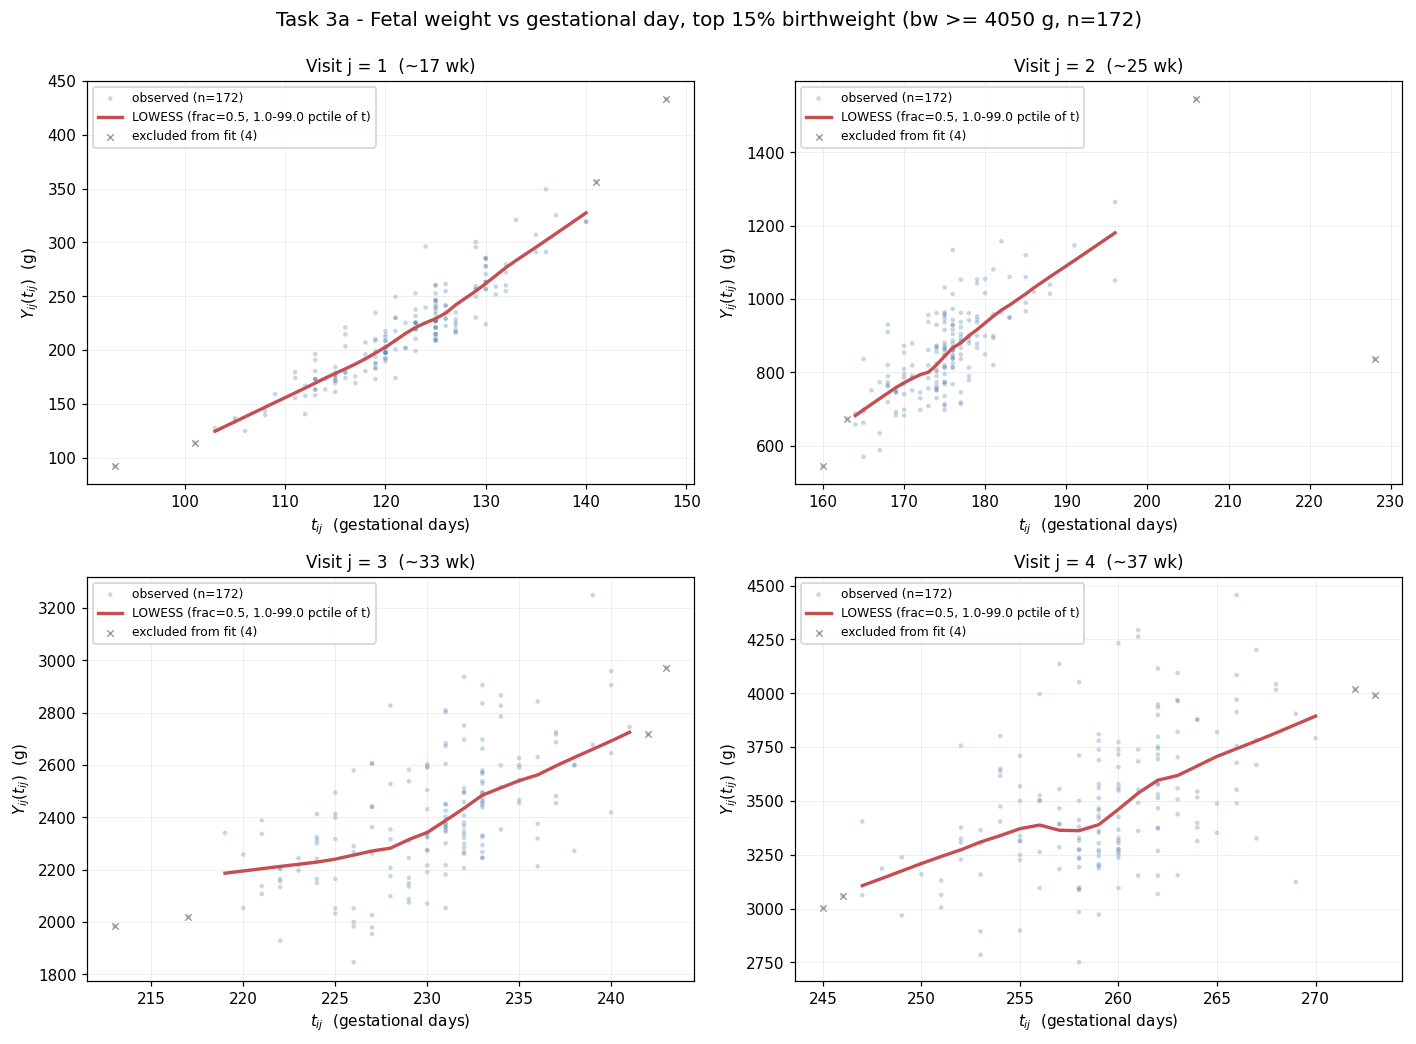

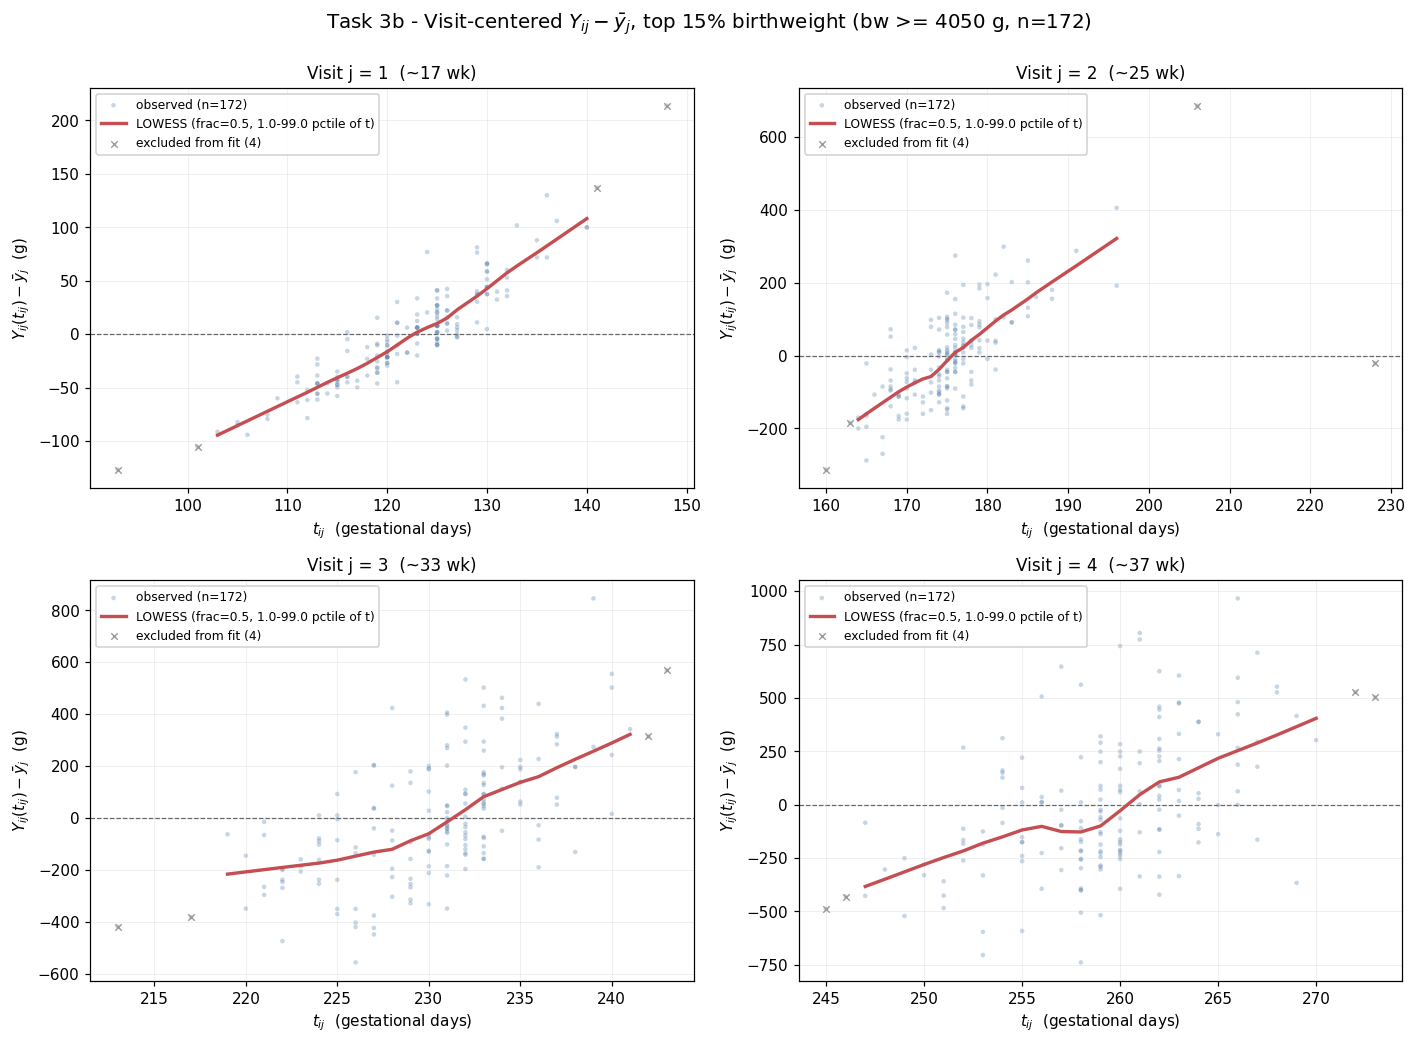

In [6]:
bw_subj = df.groupby("id")["bw"].first()
thresh = bw_subj.quantile(0.85)
top = df[df.id.isin(bw_subj[bw_subj >= thresh].index)]

print(f"85th pctile birthweight : {thresh:.0f} g")
print(f"subjects retained       : {top.id.nunique()} "
      f"({100*top.id.nunique()/df.id.nunique():.1f}%)")

make_set(top, False,
         f"Task 3a - Fetal weight vs gestational day, top 15% birthweight "
         f"(bw >= {thresh:.0f} g, n={top.id.nunique()})",
         "task3a_raw_top15")
make_set(top, True,
         r"Task 3b - Visit-centered $Y_{ij}-\bar{y}_j$, top 15% birthweight "
         f"(bw >= {thresh:.0f} g, n={top.id.nunique()})",
         "task3b_centered_top15")

## Cohort comparison

In [7]:
rows = []
for lbl, d in (("all", df), ("top15", top)):
    for j in range(1, 5):
        g = d[d.j == j]
        rows.append(dict(cohort=lbl, j=j, n=len(g),
                         ybar=round(g.efw.mean(), 1),
                         y_sd=round(g.efw.std(), 1),
                         cv=round(g.efw.std() / g.efw.mean(), 3),
                         ols_slope=round(float(np.polyfit(g.time, g.efw, 1)[0]), 2)))
comp = pd.DataFrame(rows)
print(comp.to_string(index=False))

cohort  j    n   ybar  y_sd    cv  ols_slope
   all  1 1120  215.1  48.9 0.228       5.41
   all  2 1120  804.3 114.0 0.142      14.09
   all  3 1120 2209.6 258.3 0.117      25.47
   all  4 1120 3132.8 357.2 0.114      27.12
 top15  1  172  219.2  47.9 0.219       5.67
 top15  2  172  858.4 129.2 0.150      11.60
 top15  3  172 2403.3 242.3 0.101      29.46
 top15  4  172 3489.8 323.9 0.093      33.24


## Parity check: statsmodels vs the bundled reference

Run this in Colab. It refits every visit with both backends and reports the max
absolute discrepancy in grams. Anything at the 1e-6 level is numerical noise.
A visible gap means trust `statsmodels` and regenerate the figures.

In [8]:
if not HAVE_SM:
    print("statsmodels unavailable here - run this cell in Colab.")
else:
    out = []
    for lbl, d in (("all", df), ("top15", top)):
        for j in range(1, 5):
            g = d[d.j == j]
            t, y = g.time.values, g.efw.values
            lo, hi = np.percentile(t, [TRIM, 100 - TRIM])
            m = (t >= lo) & (t <= hi)
            a = _sm_lowess(y[m], t[m], frac=FRAC, it=NIT, return_sorted=True)
            b = _lowess_ref(t[m], y[m])
            out.append(dict(cohort=lbl, j=j,
                            max_abs_diff_g=round(float(np.max(np.abs(a[:, 1] - b[:, 1]))), 6)))
    print(pd.DataFrame(out).to_string(index=False))

statsmodels unavailable here - run this cell in Colab.
